In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("flight_data-1.csv")
df.head()

,time,state,pressure,altitude,startAlt,temperature,velocity_world_x,velocity_world_y,velocity_world_z,baro_vz,...,roll,pitch,yaw,t_burnout,t_apogee,t_drogue,t_main,t_land,drogue_validated_baro,main_validated_baro
0,590889,1,937.298,652.457,650.261,44.04,-0.004,0.004,-0.043,0.155,...,21.731,-0.903,1.290,0,0,0,0,0,0,0
1,591889,1,937.335,652.132,650.261,44.04,-0.003,0.003,-0.115,-0.153,...,21.793,-1.083,0.989,0,0,0,0,0,0,0
2,592889,1,937.332,652.155,650.261,44.04,-0.006,-0.001,-0.130,-0.038,...,21.796,-1.183,1.329,0,0,0,0,0,0,0
3,593889,1,937.322,652.248,650.261,44.05,-0.008,-0.004,0.041,-0.126,...,21.862,-1.022,1.673,0,0,0,0,0,0,0
4,594889,1,937.285,652.570,650.261,44.05,-0.014,-0.014,0.079,0.118,...,21.853,-1.330,1.586,0,0,0,0,0,0,0


In [41]:
z_accel = df["lsm_accel_r"]
time = df["time"]
z_accel.head()

0    9.785
1    9.793
2    9.796
3    9.813
4    9.813
Name: lsm_accel_r, dtype: float64

In [48]:
max_accel = np.max(z_accel)
print("Max acceleration:", max_accel)

Max acceleration: 39.192


<Axes: xlabel='time', ylabel='lsm_accel_r'>

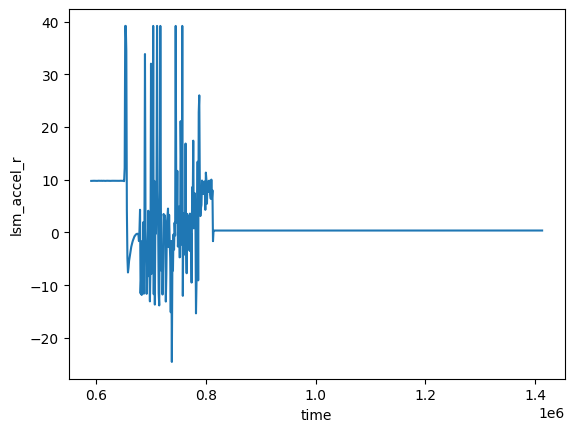

In [42]:
sns.lineplot(x=time, y=z_accel)

In [71]:
LAUNCH_THRESH_G = 1.5
BURNOUT_THRESH_G = 0.5
CONFIRM_SAMPLES = 2
SMOOTHING_WINDOW = 5

def detect_burn_start(time_ms, z_accel_raw):
    z_smooth = pd.Series(z_accel_raw).rolling(SMOOTHING_WINDOW, center=True).mean().to_numpy()
    z_g =  z_smooth / 9.81

    consecutive = 0
    for i in range(len(z_g)):
        if z_g[i] > LAUNCH_THRESH_G:
            consecutive += 1
            if consecutive >= CONFIRM_SAMPLES:
                idx = i - CONFIRM_SAMPLES + 1
                return idx, time_ms[idx]
        else:
            consecutive = 0
    
def detect_burn_end(time_ms, z_accel_raw, burn_start_idx):
    if burn_start_idx is None:
        return None, None
    
    z_smooth = pd.Series(z_accel_raw).rolling(SMOOTHING_WINDOW, center=True).mean().to_numpy()
    z_g =  z_smooth / 9.81

    consecutive = 0
    for i in range(burn_start_idx, len(z_g)):
        if z_g[i] < BURNOUT_THRESH_G:
            consecutive += 1
            if consecutive >= CONFIRM_SAMPLES:
                idx = i - CONFIRM_SAMPLES + 1
                return idx, time_ms[idx]
        else:
            consecutive = 0
    
    return None, None


In [72]:
burn_start_idx, burn_start_ms = detect_burn_start(time, z_accel)
burn_end_idx,   burn_end_ms   = detect_burn_end(time, z_accel, burn_start_idx)

print(f"Burn start: idx={burn_start_idx}, time={burn_start_ms} ms")
print(f"Burn end: idx={burn_end_idx}, time={burn_end_ms} ms")
print(f"Burn duration: {(burn_end_ms - burn_start_ms)/1000:.2f} seconds")

Burn start: idx=60, time=650890 ms
Burn end: idx=66, time=656889 ms
Burn duration: 6.00 seconds


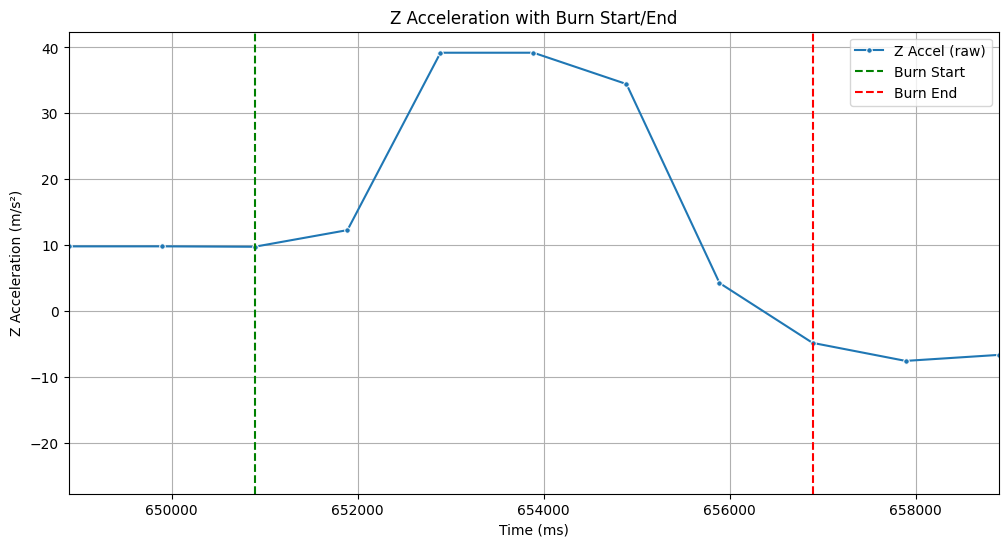

In [73]:
# Plot with burn start/end markers with zoom capability and actually show data points
plt.figure(figsize=(12, 6))
sns.lineplot(x=time, y=z_accel, label="Z Accel (raw)", marker='o', markersize=4)
if burn_start_idx is not None:
    plt.axvline(x=burn_start_ms, color='g', linestyle='--', label='Burn Start')
if burn_end_idx is not None:
    plt.axvline(x=burn_end_ms, color='r', linestyle='--', label='Burn End')
plt.xlabel("Time (ms)")
plt.ylabel("Z Acceleration (m/s²)")
plt.title("Z Acceleration with Burn Start/End")
plt.legend()
plt.xlim(burn_start_ms - 2000, burn_end_ms + 2000)
plt.grid()
plt.show()
